# Challenge: ERA5 Pressure-Level Variables

| [![leader-badge]][leader-url] |
|:-:|

[leader-badge]: https://img.shields.io/badge/leaderboard-grey?style=for-the-badge&logoColor=white

[leader-url]: https://github.com/climet-eu/compression-lab-notebooks/issues/56

You are challenged to find a compressor that produces the highest compression ratio when compressing the provided ERA5 pressure-level dataset. This challenge spans all ERA5 pressure-level variables, which you can select one at a time below. The compressor must not violate the variable's assigned safety requirements. The test data is subset to contain one timestep and four pressure levels, but feel free to use the full data once you've gotten a feeling with the smaller subset.

Please submit an issue or pull request with the [`compression-recommendations`](https://github.com/juntyr/compression-recommendations/tree/main/recommendations) repository in case you think that the provided safety requirements are insufficient.

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr

[pyodide]: Loading h5netcdf, numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loaded h5netcdf, numpy, pandas, python-dateutil, pytz, six, tzdata, xarray
[pyodide]: Loading h5py
[pyodide]: Loaded h5py
[pyodide]: Loading pyfive, typing_extensions
[pyodide]: Loaded pyfive, typing_extensions
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, fsspec, locket, partd, toolz
[pyodide]: Memory usage has grown to 107.9MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 88 new dynamic libraries (91 total for this notebook)


In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

[pyodide]: Loading Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, scipy, shapely, tqdm
[pyodide]: Loaded Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, refere

## Challenge Configuration (do not edit)

In [5]:
import json
from functools import cache, lru_cache
from pathlib import Path
from urllib.parse import urljoin

import pandas as pd
import requests

ERA5_SOURCES = {
    "pressure": {
        "ref_url": f"{BASE_URL}/ERA5_07_2026/era5_pressure_50_500_850_1000_202607_3h.grib.ref",
        "catalog_url": f"{BASE_URL}/ERA5_07_2026/era5_pressure_50_500_850_1000_202607_3h.grib.refs.json",
    },
    "single": {
        "catalog_url": f"{BASE_URL}/ERA5_07_2026/era5_single_202607_6h.grib.refs.json",
    },
}


def load_era5_data(
    leveltype=None,
    param=None,
    time=None,
    level=None,
    area=None,
    catalog_url=None,
    catalog_path=None,
    ref_url=None,
    ref_path=None,
):
    if param is None:
        raise ValueError("Please specify a GRIB short name or list of short names.")

    params = _as_list(param)
    datasets = []

    if ref_url is None and ref_path is None and leveltype in ERA5_SOURCES:
        ref_url = ERA5_SOURCES[leveltype].get("ref_url")

    if ref_url is not None or ref_path is not None:
        ds = _open_ref(ref_path or ref_url)
        datasets.append(_subset(ds, params, time, level, area))
    else:
        catalog = load_era5_catalog(leveltype, catalog_url, catalog_path)
        catalog_url = catalog_url or ERA5_SOURCES[leveltype]["catalog_url"]
        for group, group_params in _groups_for_params(catalog, params):
            ref_location = _ref_location(group["ref"], catalog_url, catalog_path)
            datasets.append(
                _subset(_open_ref(ref_location), group_params, time, level, area)
            )

    datasets = [ds for ds in datasets if ds.data_vars]
    if not datasets:
        raise ValueError("No variables matched the requested selection.")
    return (
        datasets[0]
        if len(datasets) == 1
        else xr.merge(datasets, join="outer", compat="override")
    )


def _as_list(value):
    if value is None or isinstance(value, (str, bytes)):
        return [value]
    return list(value)


def _load_json(location):
    if str(location).startswith(("http://", "https://")):
        response = requests.get(location)
        response.raise_for_status()
        return response.json()
    return json.loads(Path(location).read_text())


@cache
def _remote_json(location):
    return _load_json(location)


def _ref_location(ref_name, catalog_url=None, catalog_path=None):
    if str(ref_name).startswith(("http://", "https://")):
        return ref_name
    if catalog_path is not None:
        return Path(catalog_path).parent / ref_name
    return urljoin(catalog_url, ref_name)


def _var_name(ds, param):
    aliases = {"2t": "t2m", "2d": "d2m", "10u": "u10", "10v": "v10"}
    for name in (param, aliases.get(param)):
        if name in ds.data_vars:
            return name
    return None


def _open_ref(ref_location):
    ref = _load_json(ref_location)
    return xr.open_dataset(
        "reference://",
        engine="zarr",
        backend_kwargs={
            "storage_options": {
                "fo": ref,
                "asynchronous": True,
                "remote_options": {"asynchronous": True},
            }
        },
        consolidated=False,
        chunks={},
    )


def _subset(ds, param=None, time=None, level=None, area=None):
    if param is not None:
        params = _as_list(param)
        names = [_var_name(ds, name) for name in params]
        missing = [param for param, name in zip(params, names) if name is None]
        if missing:
            raise KeyError(
                f"Variable(s) {missing} not found in this reference group. "
                f"Available variables: {list(ds.data_vars)}"
            )
        ds = ds[names]

    if time is not None and "time" in ds.coords:
        ds = ds.sel(time=[pd.Timestamp(t) for t in _as_list(time)])
    if level is not None and "level" in ds.coords:
        ds = ds.sel(level=level)

    if area is not None:
        north, west, south, east = area
        lon_name = "longitude" if "longitude" in ds.coords else "lon"
        lat_name = "latitude" if "latitude" in ds.coords else "lat"
        lon = ds[lon_name]

        if float(lon.min()) < 0:
            west = west - 360 if west > 180 else west
            east = east - 360 if east > 180 else east
        else:
            west = west % 360
            east = east % 360

        lat_mask = (ds[lat_name] >= south) & (ds[lat_name] <= north)
        if west <= east:
            lon_mask = (lon >= west) & (lon <= east)
        else:
            lon_mask = (lon >= west) | (lon <= east)
        ds = ds.where(lat_mask & lon_mask, drop=True).sortby(lon_name)
    return ds


def _groups_for_params(catalog, params):
    matches = []
    missing = set(params)
    for group in catalog["groups"].values():
        variables = set(group.get("variables", []))
        group_params = [param for param in params if param in variables]
        if group_params:
            matches.append((group, group_params))
            missing -= set(group_params)
    if missing:
        available = sorted(
            {v for g in catalog["groups"].values() for v in g.get("variables", [])}
        )
        raise ValueError(
            f"Parameters not found: {sorted(missing)}. Available: {available}"
        )
    return matches


def load_era5_catalog(leveltype=None, catalog_url=None, catalog_path=None):
    if catalog_path is not None:
        return _load_json(catalog_path)
    if catalog_url is None:
        if leveltype not in ERA5_SOURCES:
            raise ValueError("Use leveltype='pressure' or leveltype='single'.")
        catalog_url = ERA5_SOURCES[leveltype]["catalog_url"]
    return _remote_json(catalog_url)


def era5_data_array(ds, param):
    name = _var_name(ds, param)
    if name is None:
        raise KeyError(
            f"Variable {param!r} not found. Available variables: {list(ds.data_vars)}"
        )
    return ds[name]

In [6]:
catalog = load_era5_catalog(leveltype="pressure")
variables = sorted(
    {v for group in catalog["groups"].values() for v in group["variables"]}
)

print(f"Pick one of {variables}")

Pick one of ['cc', 'ciwc', 'clwc', 'crwc', 'cswc', 'd', 'o3', 'pv', 'q', 'r', 't', 'u', 'v', 'vo', 'w', 'z']


## Variable Choice (edit here)

In [7]:
# choose which pressure-level variable to compress
VARIABLE = "u"

In [8]:
# Load the data
ds = load_era5_data(
    leveltype="pressure",
    param=VARIABLE,
)
da = ds[VARIABLE].sel(time="2026-07-15T12:00:00")

[pyodide]: Loading Deprecated, donfig, google-crc32c, numcodecs, wrapt, zarr
[pyodide]: Loaded Deprecated, donfig, google-crc32c, numcodecs, wrapt, zarr
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Loading pathlib_abc, universal_pathlib
[pyodide]: Loaded pathlib_abc, universal_pathlib
[pyodide]: Loading lz4
[pyodide]: Loaded lz4
[pyodide]: Loading ujson
[pyodide]: Loaded ujson
[pyodide]: Loading aiohappyeyeballs, aiohttp, aiosignal, frozenlist, multidict, propcache, yarl
[pyodide]: Loaded aiohappyeyeballs, aiohttp, aiosignal, frozenlist, multidict, propcache, yarl
[pyodide]: Loading pydantic_core
[pyodide]: Loaded pydantic_core
[pyodide]: Loading gribscan
[pyodide]: Loaded gribscan
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Memory usage has grown to 229.8MiB (from 129.5MiB) for this notebook
[pyodide]: Loaded 63 new dynamic libraries (161 total for this notebook)


In [9]:
# fetch the safety requirements for the pressure-level variable
from compression_recommendations import Recommendations

requirements = Recommendations.provide.search(
    markers={"grib-short-name": VARIABLE, "level-kind": "pressure"}
)

print(f"Safety Requirements for {VARIABLE!r} (all must hold):")
for req in requirements:
    print(f" - {req.humanise()}")

[pyodide]: Loading compression-recommendations, semver, strictyaml, typed_classproperties
[pyodide]: Loaded compression-recommendations, semver, strictyaml, typed_classproperties
Safety Requirements for 'u' (all must hold):
 - MaxPointwiseAbsoluteErrorBound(0.5)
[pyodide]: Memory usage has grown to 275.8MiB (from 229.8MiB) for this notebook


## Compressor Configuration (edit here)

In [10]:
from compression_requirement_safeguards import safeguards_for_requirements
from numcodecs_safeguards import SafeguardedCodec
from numcodecs_zero import ZeroCodec

codec = SafeguardedCodec(
    codec=ZeroCodec(),
    safeguards=safeguards_for_requirements(*requirements),
)

[pyodide]: Loading compression-requirement-safeguards, compression-safeguards, leb128, numcodecs-bitmap-index, numcodecs-combinators, numcodecs-delta, numcodecs-safeguards, numcodecs-shuffle, numcodecs-tokenize, numcodecs-zero, numpy_quaddtype, sly
[pyodide]: Loaded compression-requirement-safeguards, compression-safeguards, leb128, numcodecs-bitmap-index, numcodecs-combinators, numcodecs-delta, numcodecs-safeguards, numcodecs-shuffle, numcodecs-tokenize, numcodecs-zero, numpy_quaddtype, sly
[pyodide]: Loaded 1 new dynamic library (162 total for this notebook)


In [11]:
print(codec.get_config())

{'id': 'safeguards', 'codec': {'id': 'zero'}, 'safeguards': [{'kind': 'any', 'safeguards': [{'kind': 'all', 'safeguards': [{'kind': 'eb', 'type': 'abs', 'eb': 0.5, 'equal_nan': False}]}]}], 'fixed_constants': {}, 'lossless': {'for_codec': None, 'for_corrections': {'id': 'combinators.best', 'codecs': ({'id': 'combinators.stack', 'codecs': ({'id': 'tokenize'}, {'id': 'bitmap-index', 'max_bitmaps': 1, 'cost_factor': 1}, {'id': 'shuffle.typed-byte'}, {'id': 'combinators.framed', 'codecs': ({'id': 'zstd', 'level': 3, 'checksum': False},)})}, {'id': 'combinators.stack', 'codecs': ({'id': 'delta.binary'}, {'id': 'tokenize'}, {'id': 'bitmap-index', 'max_bitmaps': 1, 'cost_factor': 1}, {'id': 'shuffle.typed-byte'}, {'id': 'combinators.framed', 'codecs': ({'id': 'zstd', 'level': 3, 'checksum': False},)})})}}, 'compute': {'unstable_iterative': False, 'unstable_lossless_corrections': False}, '_version': '1.0.0'}


## Challenge Evaluation (do not edit)

In [12]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

[pyodide]: Memory usage has grown to 791.9MiB (from 275.8MiB) for this notebook


In [13]:
from compression_requirement_checks import check_safety_requirements

# check that the requirements are met
# note that the checks are not yet optimised for speed
ok = check_safety_requirements(
    original=da.values, reconstructed=da_dec.values, requirements=requirements
)

[pyodide]: Loading compression-requirement-checks
[pyodide]: Loaded compression-requirement-checks


[pyodide]: Memory usage has grown to 1.2GiB (from 791.9MiB) for this notebook


[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer


/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock
/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


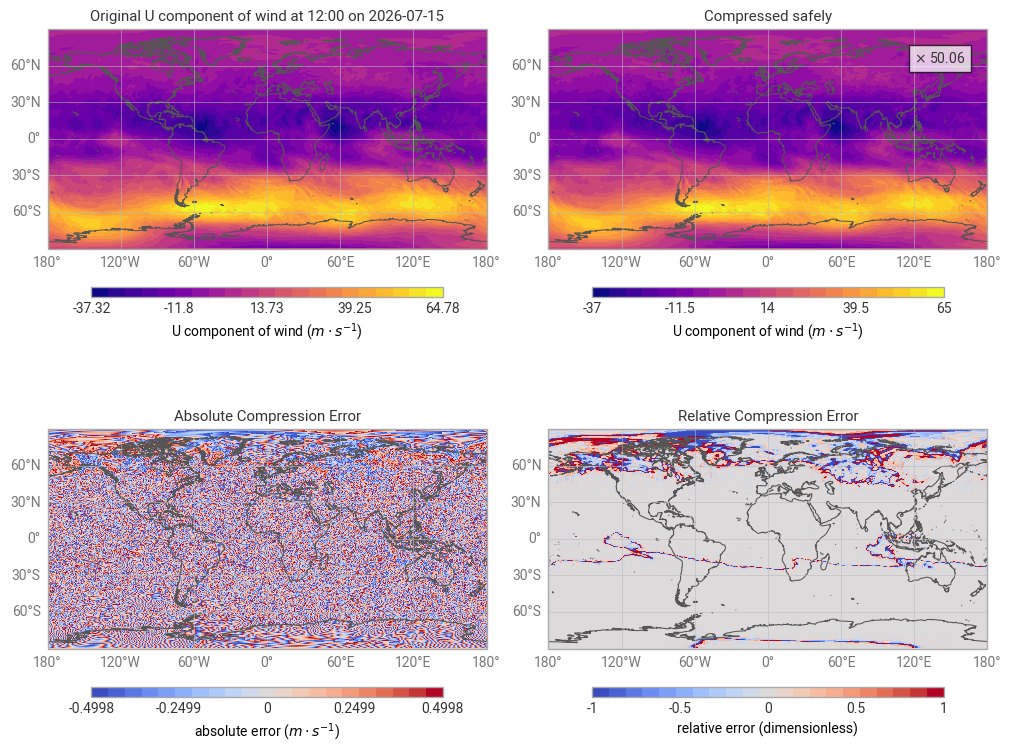

[pyodide]: Loaded 30 new dynamic libraries (192 total for this notebook)


In [14]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(10, 8),
    rows=2,
    columns=2,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec,
    fig.add_map(0, 1),
    title=f"Compressed {'safely' if ok else 'with violations'}",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    xr.where(
        (np.isnan(da) & np.isnan(da_dec)) | (da == da_dec), 0, da_dec - da
    ).assign_attrs(long_name="absolute error", units=da.units),
    fig.add_map(1, 0),
    error=True,
    title="Absolute Compression Error",
)
quickplot(
    xr.where(
        (np.isnan(da) & np.isnan(da_dec)) | (da == da_dec),
        0,
        (da_dec - da) / np.abs(da),
    ).assign_attrs(long_name="relative error", units="%"),
    fig.add_map(1, 1),
    error=True,
    title="Relative Compression Error",
)

fig.show()